<a href="https://colab.research.google.com/github/mansur264/DS-Day01/blob/main/DS_Day01_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [24]:
DATA_PATH = "DS_Day01_26_manufacturing_dataset_54750.csv"

df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df.head()

,Date,Machine_ID,Machine_Output,Downtime,Shift,Operator,Temperature,Maintenance_Status,Production_Volume
0,2026-01-01,M01,907.48,15.20,Afternoon,OP055,26.45,Normal,880.64
1,2026-01-01,M01,829.61,64.03,Morning,OP007,27.38,Normal,961.61
2,2026-01-01,M01,834.41,18.75,Night,OP099,29.98,Normal,851.22
3,2026-01-01,M02,979.43,58.25,Afternoon,OP094,30.38,Overdue,1116.93
4,2026-01-01,M02,1051.54,46.26,Morning,OP088,30.36,Normal,1160.47


In [25]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values:")
for col in ["Machine_ID", "Shift", "Operator", "Maintenance_Status"]:
    print(f"{col}: {df[col].nunique()}")

print("\nInvalid checks:")
print("Negative output:", (df["Machine_Output"] < 0).sum())
print("Negative downtime:", (df["Downtime"] < 0).sum())
print("Negative production volume:", (df["Production_Volume"] < 0).sum())

df = df.drop_duplicates().sort_values(
    ["Date", "Machine_ID", "Shift"]
).reset_index(drop=True)

print("\nFinal shape after validation:", df.shape)

Shape: (54750, 9)

Data types:
Date                  datetime64[ns]
Machine_ID                    object
Machine_Output               float64
Downtime                     float64
Shift                         object
Operator                      object
Temperature                  float64
Maintenance_Status            object
Production_Volume            float64
dtype: object

Missing values:
Date                  0
Machine_ID            0
Machine_Output        0
Downtime              0
Shift                 0
Operator              0
Temperature           0
Maintenance_Status    0
Production_Volume     0
dtype: int64

Duplicate rows: 0

Unique values:
Machine_ID: 50
Shift: 3
Operator: 100
Maintenance_Status: 4

Invalid checks:
Negative output: 0
Negative downtime: 0
Negative production volume: 0

Final shape after validation: (54750, 9)


In [26]:
df.describe().round(2)

,Date,Machine_Output,Downtime,Temperature,Production_Volume
count,54750,54750.00,54750.00,54750.00,54750.00
mean,2026-07-02 00:00:00,960.30,35.22,29.07,1046.66
min,2026-01-01 00:00:00,574.77,1.50,14.86,718.56
25%,2026-04-02 00:00:00,876.69,21.32,25.73,963.38
50%,2026-07-02 00:00:00,954.62,32.40,29.09,1037.97
75%,2026-10-01 00:00:00,1042.46,46.07,32.39,1125.30
max,2026-12-31 00:00:00,1338.67,162.74,42.24,1425.90
std,NaN,118.14,19.12,4.23,111.37


In [27]:
# Planned shift time: 8 hours = 480 minutes
df["Availability"] = (480 - df["Downtime"]) / 480

# Actual production compared with planned production
df["Production_Attainment"] = (
    df["Machine_Output"] / df["Production_Volume"]
)

# Production loss
df["Production_Loss"] = (
    df["Production_Volume"] - df["Machine_Output"]
)

# Number of days since the beginning of the dataset
df["Days_Since_Start"] = (
    df["Date"] - df["Date"].min()
).dt.days

df[[
    "Machine_Output",
    "Downtime",
    "Availability",
    "Production_Attainment",
    "Production_Loss"
]].describe().round(3)

,Machine_Output,Downtime,Availability,Production_Attainment,Production_Loss
count,54750.000,54750.000,54750.000,54750.000,54750.000
mean,960.296,35.225,0.927,0.919,86.363
std,118.138,19.125,0.040,0.073,78.241
min,574.770,1.500,0.661,0.603,-170.050
25%,876.693,21.320,0.904,0.876,31.070
50%,954.620,32.405,0.932,0.929,74.270
75%,1042.458,46.070,0.956,0.970,131.230
max,1338.670,162.740,0.997,1.175,469.500


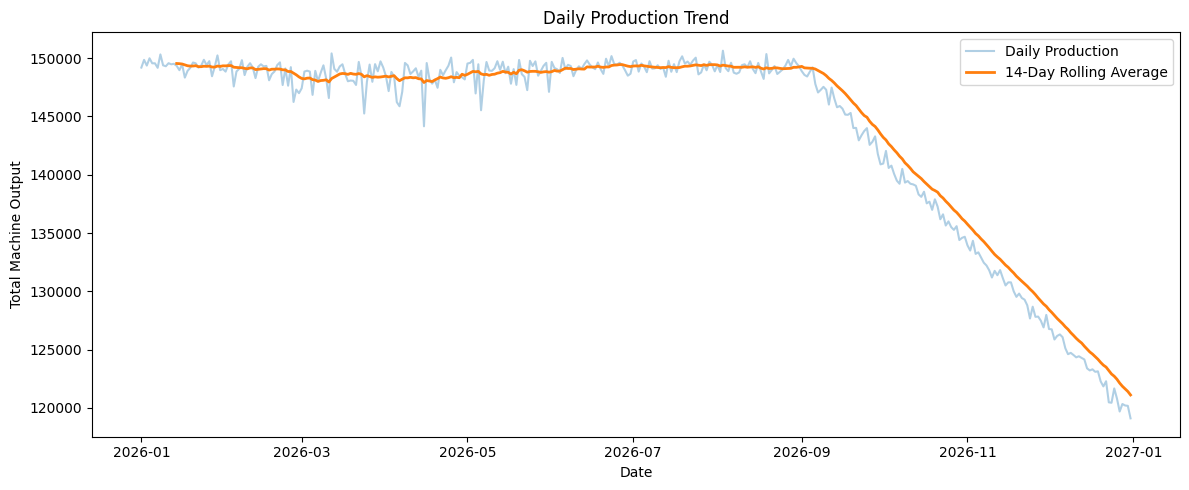

In [28]:
daily_output = (
    df.groupby("Date", as_index=False)["Machine_Output"]
      .sum()
)

daily_output["Rolling_14D"] = (
    daily_output["Machine_Output"].rolling(14).mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_output["Date"],
    daily_output["Machine_Output"],
    alpha=0.35,
    label="Daily Production"
)

plt.plot(
    daily_output["Date"],
    daily_output["Rolling_14D"],
    linewidth=2,
    label="14-Day Rolling Average"
)

plt.xlabel("Date")
plt.ylabel("Total Machine Output")
plt.title("Daily Production Trend")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Compare the current 14-day rolling average
# with the rolling average from 14 days earlier.

daily_output["Previous_14D_Rolling"] = (
    daily_output["Rolling_14D"].shift(14)
)

daily_output["Rolling_Change"] = (
    daily_output["Rolling_14D"] /
    daily_output["Previous_14D_Rolling"] - 1
)

# Define a meaningful decline as >2% reduction
# compared with the previous 14-day period.
decline_candidates = daily_output[
    daily_output["Rolling_Change"] < -0.02
]

if len(decline_candidates) > 0:
    decline_start = decline_candidates.iloc[0]["Date"]

    print(
        "Meaningful sustained decline detected from:",
        decline_start.date()
    )
else:
    print("No meaningful decline detected.")

print("\nFirst decline candidates:")

print(
    decline_candidates.head(10)[
        [
            "Date",
            "Rolling_14D",
            "Previous_14D_Rolling",
            "Rolling_Change"
        ]
    ].round(4)
)

Meaningful sustained decline detected from: 2026-09-21

First decline candidates:
          Date  Rolling_14D  Previous_14D_Rolling  Rolling_Change
263 2026-09-21  145935.2821           148939.0664         -0.0202
264 2026-09-22  145625.9707           148813.0779         -0.0214
265 2026-09-23  145329.0386           148683.0514         -0.0226
266 2026-09-24  145076.3700           148500.2293         -0.0231
267 2026-09-25  144932.1779           148264.7307         -0.0225
268 2026-09-26  144580.9707           148088.1929         -0.0237
269 2026-09-27  144316.1286           147870.5400         -0.0240
270 2026-09-28  144137.7043           147619.5693         -0.0236
271 2026-09-29  143844.0229           147405.8364         -0.0242
272 2026-09-30  143503.0071           147198.6843         -0.0251


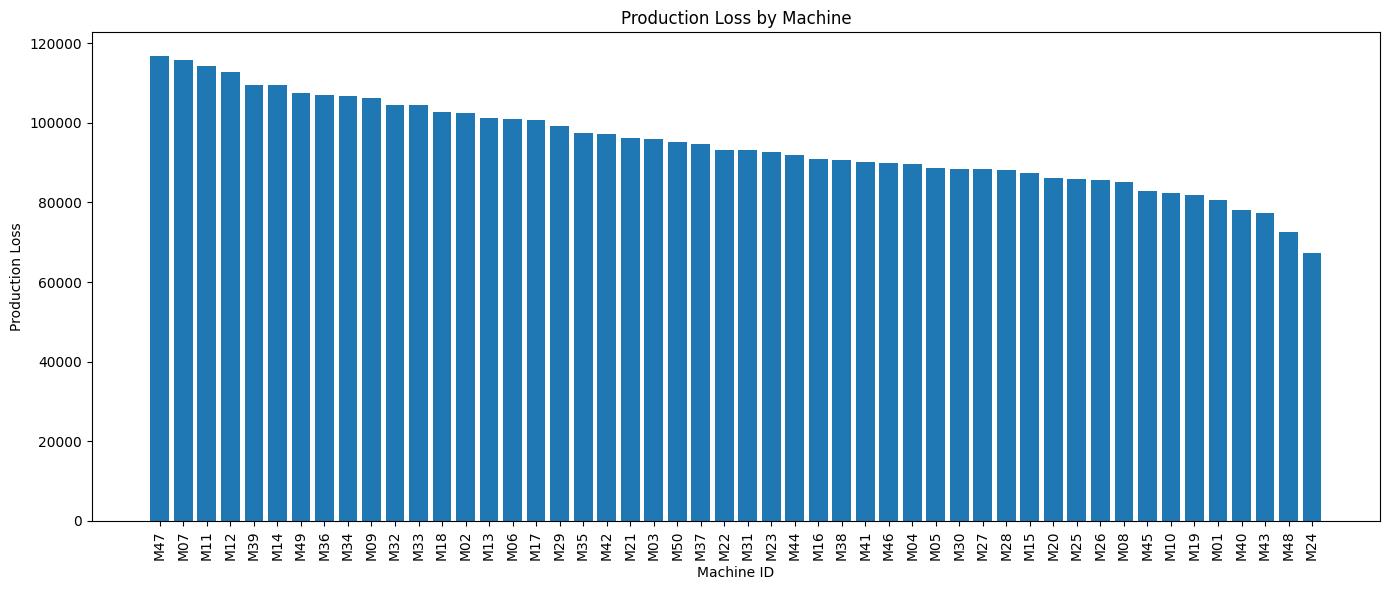

Top 10 machines by production loss:


,Actual_Output,Planned_Output,Total_Downtime,Production_Loss
Machine_ID,,,,
M47,1059348.40,1176241.72,50445.58,116893.32
M07,1200200.32,1316069.26,42619.31,115868.94
M11,1233446.12,1347635.82,38644.66,114189.70
M12,1212826.93,1325495.47,39645.27,112668.54
M39,1207240.51,1316792.79,38058.04,109552.28
M14,1143051.08,1252549.89,42798.97,109498.81
M49,1135818.44,1243409.77,41449.46,107591.33
M36,1228377.48,1335411.64,37468.73,107034.16
M34,1080613.90,1187238.67,44411.25,106624.77


In [30]:
machine_summary = (
    df.groupby("Machine_ID")
      .agg(
          Actual_Output=("Machine_Output", "sum"),
          Planned_Output=("Production_Volume", "sum"),
          Total_Downtime=("Downtime", "sum")
      )
)

machine_summary["Production_Loss"] = (
    machine_summary["Planned_Output"] -
    machine_summary["Actual_Output"]
)

machine_summary = machine_summary.sort_values(
    "Production_Loss",
    ascending=False
)

plt.figure(figsize=(14, 6))

plt.bar(
    machine_summary.index,
    machine_summary["Production_Loss"]
)

plt.xlabel("Machine ID")
plt.ylabel("Production Loss")
plt.title("Production Loss by Machine")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Top 10 machines by production loss:")

display(
    machine_summary.head(10).round(2)
)

In [31]:
downtime_by_machine = (
    df.groupby("Machine_ID")
      .agg(
          Avg_Downtime=("Downtime", "mean"),
          Total_Downtime=("Downtime", "sum")
      )
      .sort_values(
          "Total_Downtime",
          ascending=False
      )
)

print("Top machines by total downtime:")

display(
    downtime_by_machine.head(10).round(2)
)

Top machines by total downtime:


,Avg_Downtime,Total_Downtime
Machine_ID,,
M47,46.07,50445.58
M18,43.20,47298.62
M31,42.24,46250.88
M42,40.60,44454.77
M34,40.56,44411.25
M09,40.52,44365.67
M29,40.49,44338.17
M35,40.43,44266.34
M17,39.82,43603.94


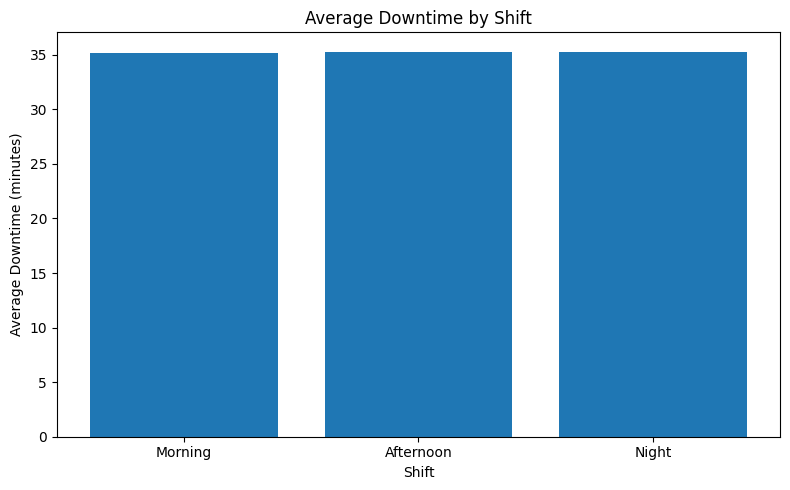

,Avg_Output,Avg_Downtime,Avg_Attainment
Shift,,,
Morning,1005.460,35.177,0.918
Afternoon,966.568,35.287,0.919
Night,908.860,35.209,0.919


In [32]:
shift_summary = (
    df.groupby("Shift")
      .agg(
          Avg_Output=("Machine_Output", "mean"),
          Avg_Downtime=("Downtime", "mean"),
          Avg_Attainment=("Production_Attainment", "mean")
      )
      .sort_values(
          "Avg_Output",
          ascending=False
      )
)

plt.figure(figsize=(8, 5))

plt.bar(
    shift_summary.index,
    shift_summary["Avg_Downtime"]
)

plt.xlabel("Shift")
plt.ylabel("Average Downtime (minutes)")
plt.title("Average Downtime by Shift")

plt.tight_layout()
plt.show()

display(
    shift_summary.round(3)
)

In [33]:
operator_summary = (
    df.groupby("Operator")
      .agg(
          Avg_Output=("Machine_Output", "mean"),
          Avg_Downtime=("Downtime", "mean"),
          Avg_Attainment=("Production_Attainment", "mean"),
          Records=("Machine_Output", "size")
      )
      .sort_values(
          "Avg_Output",
          ascending=False
      )
)

display(
    operator_summary.round(3)
)

print(
    "Operator results are aggregate observations only; "
    "they should not be interpreted as evidence that an individual "
    "caused production losses."
)

,Avg_Output,Avg_Downtime,Avg_Attainment,Records
Operator,,,,
OP012,983.601,35.503,0.937,517
OP009,982.949,35.992,0.941,548
OP087,980.527,34.965,0.933,547
OP082,980.128,35.164,0.935,574
OP024,978.247,35.023,0.929,574
...,...,...,...,...
OP003,943.847,35.603,0.907,554
OP069,943.048,36.842,0.911,571
OP095,942.327,35.827,0.904,574


Operator results are aggregate observations only; they should not be interpreted as evidence that an individual caused production losses.


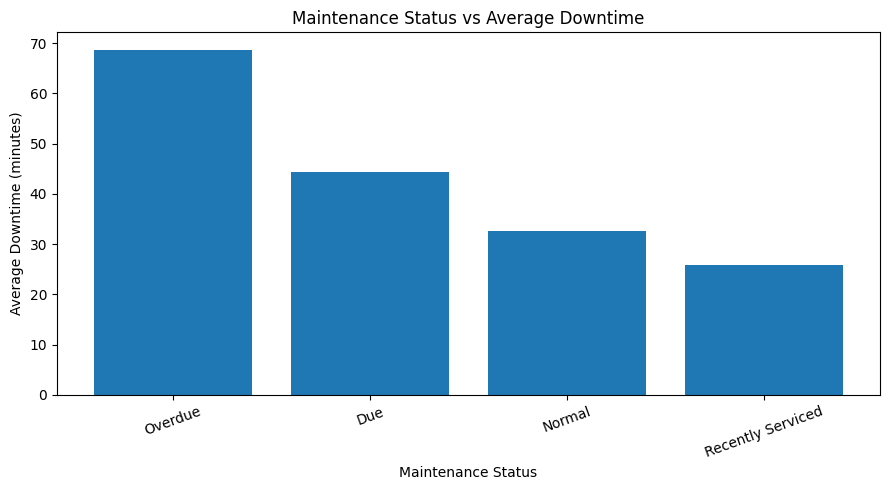

,Avg_Downtime,Avg_Output,Avg_Attainment,Records
Maintenance_Status,,,,
Overdue,68.715,896.633,0.856,2607
Due,44.454,945.025,0.904,8082
Normal,32.545,965.229,0.923,37433
Recently Serviced,25.929,976.095,0.934,6628


In [34]:
maintenance_summary = (
    df.groupby("Maintenance_Status")
      .agg(
          Avg_Downtime=("Downtime", "mean"),
          Avg_Output=("Machine_Output", "mean"),
          Avg_Attainment=("Production_Attainment", "mean"),
          Records=("Machine_Output", "size")
      )
      .sort_values(
          "Avg_Downtime",
          ascending=False
      )
)

plt.figure(figsize=(9, 5))

plt.bar(
    maintenance_summary.index,
    maintenance_summary["Avg_Downtime"]
)

plt.xlabel("Maintenance Status")
plt.ylabel("Average Downtime (minutes)")
plt.title("Maintenance Status vs Average Downtime")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

display(
    maintenance_summary.round(3)
)

In [35]:
# Standard OEE = Availability × Performance × Quality

# Each record represents an 8-hour shift = 480 planned minutes.
df["Availability"] = (
    (480 - df["Downtime"]) / 480
)

# Production attainment is used as a performance proxy.
df["Performance_Proxy"] = (
    df["Machine_Output"] /
    df["Production_Volume"]
)

oee_summary = pd.DataFrame({
    "Metric": [
        "Average Availability",
        "Average Production Performance Proxy"
    ],
    "Value": [
        df["Availability"].mean(),
        df["Performance_Proxy"].mean()
    ]
})

display(
    oee_summary.round(4)
)

print(
    "Full standard OEE is not calculated because "
    "ideal cycle time and good/rejected unit counts "
    "are unavailable in the dataset."
)

,Metric,Value
0,Average Availability,0.9266
1,Average Production Performance Proxy,0.9186


Full standard OEE is not calculated because ideal cycle time and good/rejected unit counts are unavailable in the dataset.


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Features and target
features = [
    "Days_Since_Start",
    "Downtime",
    "Temperature",
    "Production_Volume",
    "Machine_ID",
    "Shift",
    "Operator",
    "Maintenance_Status"
]

X = df[features]
y = df["Machine_Output"]

# Chronological 80/20 split
# This avoids using future observations to predict earlier observations.
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Numerical and categorical features
numeric_features = [
    "Days_Since_Start",
    "Downtime",
    "Temperature",
    "Production_Volume"
]

categorical_features = [
    "Machine_ID",
    "Shift",
    "Operator",
    "Maintenance_Status"
]

# One-hot encode categorical variables
preprocessor = ColumnTransformer([
    (
        "numeric",
        "passthrough",
        numeric_features
    ),
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    )
])

# Random Forest
rf = RandomForestRegressor(
    n_estimators=60,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

# Complete pipeline
model = Pipeline([
    ("preprocessor", preprocessor),
    ("random_forest", rf)
])

# Train
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = mean_squared_error(
    y_test,
    predictions
) ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print("Random Forest Evaluation")
print("------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Random Forest Evaluation
------------------------
MAE  : 61.71
RMSE : 73.05
R²   : 0.4592


In [37]:
# Get encoded feature names
encoded_names = model.named_steps[
    "preprocessor"
].get_feature_names_out()

# Get Random Forest importance
importances = model.named_steps[
    "random_forest"
].feature_importances_

importance_df = pd.DataFrame({
    "Feature": encoded_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

print("Top 15 model features:")
display(
    importance_df.head(15).round(4)
)

Top 15 model features:


,Feature,Importance
3,numeric__Production_Volume,0.8349
1,numeric__Downtime,0.1042
0,numeric__Days_Since_Start,0.0219
56,categorical__Shift_Night,0.0063
2,numeric__Temperature,0.0042
27,categorical__Machine_ID_M24,0.0036
55,categorical__Shift_Morning,0.0028
14,categorical__Machine_ID_M11,0.0016
39,categorical__Machine_ID_M36,0.0014
54,categorical__Shift_Afternoon,0.0011


In [38]:
def base_feature(name):
    if name.startswith("numeric__"):
        return name.replace("numeric__", "")

    if name.startswith("categorical__"):
        rest = name.replace("categorical__", "")

        for col in categorical_features:
            prefix = f"{col}_"
            if rest.startswith(prefix):
                return col

        return rest

    return name


importance_df["Base_Feature"] = importance_df["Feature"].apply(base_feature)

aggregated_importance = (
    importance_df
    .groupby("Base_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

print("Corrected Aggregated Feature Importance:")
display(aggregated_importance)

Corrected Aggregated Feature Importance:


,Base_Feature,Importance
5,Production_Volume,0.834892
1,Downtime,0.104164
0,Days_Since_Start,0.021945
2,Machine_ID,0.021750
6,Shift,0.010286
7,Temperature,0.004209
4,Operator,0.001939
3,Maintenance_Status,0.000816


In [39]:
import joblib

joblib.dump(
    model,
    "manufacturing_random_forest.pkl"
)

print("Random Forest model saved successfully.")

Random Forest model saved successfully.


In [40]:
print("1. Production decline:")
print(
    f"   The selected 2% rolling-decline rule identifies "
    f"{decline_start.date()} as the start of the meaningful decline."
)

top_machine = machine_summary.index[0]

print("\n2. Largest production loss:")
print(
    f"   {top_machine} has the largest gap between planned "
    f"and actual output "
    f"({machine_summary.loc[top_machine, 'Production_Loss']:,.0f} units)."
)

worst_maintenance = maintenance_summary.index[0]
best_maintenance = maintenance_summary.index[-1]

print("\n3. Maintenance relationship:")
print(
    f"   {worst_maintenance} has the highest average downtime "
    f"({maintenance_summary.loc[worst_maintenance, 'Avg_Downtime']:.2f} min), "
    f"while {best_maintenance} has the lowest "
    f"({maintenance_summary.loc[best_maintenance, 'Avg_Downtime']:.2f} min)."
)

print("\n4. Shift comparison:")

for shift_name, row in shift_summary.iterrows():
    print(
        f"   {shift_name}: "
        f"{row['Avg_Output']:.2f} average output, "
        f"{row['Avg_Downtime']:.2f} min average downtime."
    )

print("\n5. Operator comparison:")
print(
    "   Operator differences are aggregate observations only "
    "and should not be treated as proof of individual causation."
)

print("\n6. OEE limitation:")
print(
    "   Availability is calculable, but full standard OEE is not "
    "because ideal cycle time and good/rejected counts are absent."
)

print("\n7. Random Forest:")
print(
    f"   Test MAE = {mae:.2f}, "
    f"RMSE = {rmse:.2f}, "
    f"R² = {r2:.4f}."
)

print(
    "   Review the aggregated feature importance table "
    "to identify the strongest predictive drivers."
)

1. Production decline:
   The selected 2% rolling-decline rule identifies 2026-09-21 as the start of the meaningful decline.

2. Largest production loss:
   M47 has the largest gap between planned and actual output (116,893 units).

3. Maintenance relationship:
   Overdue has the highest average downtime (68.71 min), while Recently Serviced has the lowest (25.93 min).

4. Shift comparison:
   Morning: 1005.46 average output, 35.18 min average downtime.
   Afternoon: 966.57 average output, 35.29 min average downtime.
   Night: 908.86 average output, 35.21 min average downtime.

5. Operator comparison:
   Operator differences are aggregate observations only and should not be treated as proof of individual causation.

6. OEE limitation:
   Availability is calculable, but full standard OEE is not because ideal cycle time and good/rejected counts are absent.

7. Random Forest:
   Test MAE = 61.71, RMSE = 73.05, R² = 0.4592.
   Review the aggregated feature importance table to identify the s

In [41]:
import os

model_path = "manufacturing_random_forest.pkl"

if os.path.exists(model_path):
    print("✅ Random Forest model saved successfully.")
    print(f"File size: {os.path.getsize(model_path) / 1024:.2f} KB")
else:
    print("❌ Model file not found. We need to save it.")

✅ Random Forest model saved successfully.
File size: 13556.84 KB
